# Classifier performance and measured learning curves

Read saved results, inspect the numbers, draw figures, and export a new snapshot.
This notebook runs independently of the other notebooks.
`OWNED_TABLES` below lists the CSVs exported here; figure names appear in
the drawing cells.

**Inputs:** all saved classifier summaries/histories and planned run populations. No training, additional network inference, or UMAP runs here.
**Use:** run from the top once. For presentation edits, rerun only that chapter's
display-settings and drawing cells. For changes to inputs or display targets,
restart the kernel and run all cells so that every chapter uses the same conditions.
Save the notebook file before exporting to include your code in the source copy.

## 1. Settings

Shared defaults are in `figure_settings.py`; the next cell reloads them.
`DISPLAY_TARGETS=None` selects the lowest seed-median final classifier validation
loss for each model. Ties within absolute 1e-6 (relative tolerance zero) choose
the smaller target. A model dictionary changes the display only; HP eta selection
remains unchanged. PDF is OFF by default. Viewing creates no files.

In [1]:
from pathlib import Path
import sys
import json
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "experiment_settings.py").is_file() and (p / "src/hnn2").is_dir())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "notebooks"))
import figure_settings
defaults = importlib.reload(figure_settings)

from hnn2.figure_tables import THRESHOLDS, _identity, _display_population, load_figure_runs, require_complete, analysis_target_tables, check_figure_inputs, selected_runs, validation_points, save_figure_tables
from hnn2.artifact_checks import readout_issues
from hnn2.plots import MODEL_COLORS
from hnn2.figure_plots import _points, _violin_points, _arm_label, save_basic_figures

In [2]:
RESULTS = Path(defaults.RESULTS_ROOT)
OUTPUT = Path(defaults.OUTPUT)
DISPLAY_TARGETS = defaults.DISPLAY_TARGETS
SAVE_NUMBERS = defaults.SAVE_NUMBERS
SAVE_PNG = defaults.SAVE_PNG
SAVE_PDF = defaults.SAVE_PDF  # False by default; enable explicitly when needed.
SHOW_FIGURES = defaults.SHOW_FIGURES
EXPORT_NAME = defaults.EXPORT_NAME

In [3]:
NOTEBOOK_OWNER = 'classifier'
NOTEBOOK_PATH = ROOT / "notebooks" / '04_classifier.ipynb'
OWNED_TABLES = ['summary', 'selected_summary', 'accuracy_statistics', 'paired_accuracy', 'accuracy_differences', 'history', 'validation_points', 'validation_trajectory', 'threshold_detail', 'threshold_summary']

## 2. Load and check results

All five result notebooks require the complete saved run artifacts, planned
run lists, HP selection, and recorded dataset files, even when a chapter uses
only some of those inputs. The coverage table includes every planned run,
including missing or invalid runs. The notebook stops on incomplete data.

Source hashes, HP eta, scientific conditions, budgets, and seed populations
are checked before comparisons. Effective targets and displayed seeds below
are the conditions for this kernel.

In [4]:
selection_directory = RESULTS / "hp/selection"
runs, expected = load_figure_runs(RESULTS)
display(expected.groupby(["arm", "state"], dropna=False).size().rename("runs").reset_index())
display(expected.loc[expected.state != "complete", ["run", "state", "reason"]])
require_complete(expected)

# Assemble all targets before applying the shared display-selection rule.
parts = []
for path, (conditions, arrays, saved) in runs.items():
    frame = saved["summary"].assign(**_identity(path, conditions))
    frame["n_readout_parameters"] = (frame.n_features + 1) * frame.n_classes
    frame["final_model"] = "last_step; best_val_accuracy is monitoring_only"
    frame["readout_eval_every"] = conditions["config"]["readout_eval_every"]
    frame["readout_epochs"] = conditions["config"]["readout_epochs"]
    parts.append(frame)
summary = pd.concat(parts, ignore_index=True)
candidates, effective = analysis_target_tables(summary, DISPLAY_TARGETS)
targets = effective.set_index("model_code").targ.to_dict()
report, coverage = check_figure_inputs(runs, expected, selection_directory, targets)
selected = selected_runs(runs, targets)
chosen_paths = set(selected)
chosen = summary[summary.run.isin(chosen_paths)].reset_index(drop=True)
models = [model for model in ("rec", "ff", "thresh") if model in targets]
arms = [f"{model}_{stage}" for model in models for stage in ("initial", "trained")] + ["raw", "mlp_frozen"]
arm_labels = [_arm_label(arm, targets) for arm in arms]
tables = {"summary": summary, "selected_summary": chosen}
figures = {}
display(effective)
display(chosen.groupby("arm").seed_index.agg(list).rename("displayed_seeds").to_frame())
print(f"Input: {RESULTS.resolve()}\nOutput: {OUTPUT.resolve()}")
print("Invalid or missing planned runs:", int(coverage.state.ne("complete").sum()))

,arm,state,runs
0,ff_initial,complete,3
1,ff_trained,complete,27
2,mlp_frozen,complete,3
3,raw,complete,3
4,rec_initial,complete,3
5,rec_trained,complete,27
6,thresh_initial,complete,3
7,thresh_trained,complete,27


,run,state,reason


,model_code,targ,method,median_final_val_loss,tiebreak
0,ff,0.55,median_final_val_loss,0.449672,absolute difference <= 1e-06 from the best see...
1,rec,0.17,median_final_val_loss,0.368852,absolute difference <= 1e-06 from the best see...
2,thresh,1.55,median_final_val_loss,0.649693,absolute difference <= 1e-06 from the best see...


,displayed_seeds
arm,
ff_initial,"[0, 1, 2]"
ff_trained,"[0, 1, 2]"
mlp_frozen,"[0, 1, 2]"
raw,"[0, 1, 2]"
rec_initial,"[0, 1, 2]"
rec_trained,"[0, 1, 2]"
thresh_initial,"[0, 1, 2]"
thresh_trained,"[0, 1, 2]"


Input: outputs\synthetic_long_v1\results
Output: outputs\synthetic_long_v1\analysis\notebook_figures_v2
Invalid or missing planned runs: 0


### Statistics used in this notebook

Grouping columns are stated at each call below. This small local helper keeps
every finite seed, counts missing/nonfinite values, uses population SD (`ddof=0`),
and uses linear quartiles. Undefined values stay undefined.

In [5]:
def describe_values(frame, groups, columns):
    """Explicit finite n and missing n; SD is population SD (ddof=0)."""
    rows = []
    for coords, g in frame.groupby(groups, dropna=False, sort=True):
        coords = coords if isinstance(coords, tuple) else (coords,)
        identity = dict(zip(groups, coords))
        for key in columns:
            values = g[key].to_numpy(float)
            finite = values[np.isfinite(values)]
            rows.append({**identity, "metric": key, "expected_n": len(values), "n": len(finite),
                         "missing_or_invalid": len(values) - len(finite),
                         "mean": finite.mean() if len(finite) else np.nan,
                         "sd": finite.std(ddof=0) if len(finite) else np.nan,
                         "median": np.median(finite) if len(finite) else np.nan,
                         "q1": np.quantile(finite, .25) if len(finite) else np.nan,
                         "q3": np.quantile(finite, .75) if len(finite) else np.nan,
                         "min": finite.min() if len(finite) else np.nan,
                         "max": finite.max() if len(finite) else np.nan})
    return pd.DataFrame(rows)

### Export helper

Chapter saves are opt-in at the end of each chapter. The final export saves
the CSVs listed in `OWNED_TABLES` and the prepared main-chapter figures.
Each save uses a **new name** under `OUTPUT / NOTEBOOK_OWNER`; existing
folders are rejected. Change the name after editing a figure.

PNG and PDF use the switches above. Numeric tables and source records are
saved even if both image switches are OFF.

In [6]:
def export_section(name, figure_names, table_names):
    """Save this chapter to a new directory with its numeric sources."""
    if Path(name).name != name or name in ("", ".", ".."):
        raise ValueError("Use a simple new export name, without directories")
    if not set(table_names) <= set(OWNED_TABLES):
        raise ValueError("Only this notebook's tables may be exported")
    destination = OUTPUT / NOTEBOOK_OWNER / name
    if destination.exists():
        raise FileExistsError(f"Choose a new export name: {destination}")
    # Resolve selections before creating files, so a missing chapter fails early.
    numeric = {key: tables[key] for key in table_names}
    images = {key: figures[key] for key in figure_names}
    numeric_path = save_figure_tables(
        destination / "tables/figures", numeric, runs, targets=targets,
        selection_directory=selection_directory, notebook_path=NOTEBOOK_PATH,
        coverage=coverage, analysis_targets=effective,
    )
    settings = {"results": str(RESULTS.resolve()), "output": str(OUTPUT.resolve()),
                "display_targets": DISPLAY_TARGETS, "effective_targets": targets,
                "png": SAVE_PNG, "pdf": SAVE_PDF, "export_name": name,
                "figures": list(images), "tables": list(numeric)}
    (numeric_path / "notebook_settings.json").write_text(
        json.dumps(settings, indent=2), encoding="utf-8")
    save_basic_figures(images, destination / "figures", png=SAVE_PNG,
                       pdf=SAVE_PDF, numeric_source=numeric_path)
    print(f"Saved: {destination}")
    return destination

## 3. Final accuracy

Use the final classifier model. Best validation accuracy remains monitoring-only. Full-test accuracy and ordinary test accuracy stay distinct.

In [7]:
# Statistics retain all saved targets; the accuracy figure uses the selected runs.
tables["accuracy_statistics"] = describe_values(tables["summary"], ["arm", "targ"], ["final_test_accuracy", "final_test_accuracy_full", "final_val_accuracy"])

In [8]:
for name in ['summary', 'selected_summary', 'accuracy_statistics']:
    print(f"{name}: {len(tables[name])} rows (preview below; export keeps every row)")
    display(tables[name].head(12).rename(columns={"lifetime": "dataset"}).replace({"axis": {"lifetime": "dataset"}}))

summary: 96 rows (preview below; export keeps every row)


,best_val_accuracy,final_val_accuracy,final_test_accuracy,final_test_accuracy_full,n_features,n_classes,final_val_loss,final_step,final_cumulative_l1,run,arm,model_code,targ,eta,seed_index,n_readout_parameters,final_model,readout_eval_every,readout_epochs
0,0.849609,0.849609,0.852539,0.8492,484,10,0.724346,240,690.707160,[local path],ff_trained,ff,0.17,0.0003,0,4850,last_step; best_val_accuracy is monitoring_only,1,15
1,0.889648,0.889648,0.881836,0.8822,484,10,0.472116,240,698.276295,[local path],ff_trained,ff,0.17,0.0003,1,4850,last_step; best_val_accuracy is monitoring_only,1,15
2,0.855469,0.851562,0.865234,0.8447,484,10,0.683691,240,657.068289,[local path],ff_trained,ff,0.17,0.0003,2,4850,last_step; best_val_accuracy is monitoring_only,1,15
3,0.874023,0.869141,0.877930,0.8730,484,10,0.597566,240,631.280215,[local path],ff_trained,ff,0.27,0.0001,0,4850,last_step; best_val_accuracy is monitoring_only,1,15
4,0.891602,0.891602,0.881836,0.8852,484,10,0.421395,240,623.988124,[local path],ff_trained,ff,0.27,0.0001,1,4850,last_step; best_val_accuracy is monitoring_only,1,15
5,0.875000,0.871094,0.871094,0.8644,484,10,0.547187,240,601.291007,[local path],ff_trained,ff,0.27,0.0001,2,4850,last_step; best_val_accuracy is monitoring_only,1,15
6,0.860352,0.858398,0.861328,0.8601,484,10,0.675552,240,670.852553,[local path],ff_trained,ff,0.20,0.0003,0,4850,last_step; best_val_accuracy is monitoring_only,1,15
7,0.892578,0.888672,0.876953,0.8840,484,10,0.449294,240,670.949394,[local path],ff_trained,ff,0.20,0.0003,1,4850,last_step; best_val_accuracy is monitoring_only,1,15
8,0.865234,0.860352,0.872070,0.8531,484,10,0.631357,240,639.323194,[local path],ff_trained,ff,0.20,0.0003,2,4850,last_step; best_val_accuracy is monitoring_only,1,15
9,0.879883,0.875977,0.875977,0.8781,484,10,0.546541,240,594.510985,[local path],ff_trained,ff,0.35,0.0001,0,4850,last_step; best_val_accuracy is monitoring_only,1,15


selected_summary: 24 rows (preview below; export keeps every row)


,best_val_accuracy,final_val_accuracy,final_test_accuracy,final_test_accuracy_full,n_features,n_classes,final_val_loss,final_step,final_cumulative_l1,run,arm,model_code,targ,eta,seed_index,n_readout_parameters,final_model,readout_eval_every,readout_epochs
0,0.877930,0.871094,0.876953,0.8775,484,10,0.495633,240,525.802124,[local path],ff_trained,ff,0.55,0.0001,0,4850,last_step; best_val_accuracy is monitoring_only,1,15
1,0.886719,0.880859,0.878906,0.8801,484,10,0.433471,240,544.786494,[local path],ff_trained,ff,0.55,0.0001,1,4850,last_step; best_val_accuracy is monitoring_only,1,15
2,0.878906,0.876953,0.868164,0.8724,484,10,0.449672,240,550.952654,[local path],ff_trained,ff,0.55,0.0001,2,4850,last_step; best_val_accuracy is monitoring_only,1,15
3,0.901367,0.901367,0.894531,0.8989,484,10,0.379146,240,696.031220,[local path],rec_trained,rec,0.17,0.0010,0,4850,last_step; best_val_accuracy is monitoring_only,1,15
4,0.902344,0.896484,0.892578,0.8952,484,10,0.362268,240,685.786947,[local path],rec_trained,rec,0.17,0.0010,1,4850,last_step; best_val_accuracy is monitoring_only,1,15
5,0.898438,0.898438,0.894531,0.8962,484,10,0.368852,240,687.155048,[local path],rec_trained,rec,0.17,0.0010,2,4850,last_step; best_val_accuracy is monitoring_only,1,15
6,0.852539,0.822266,0.838867,0.8344,484,10,0.649693,240,384.578315,[local path],thresh_trained,thresh,1.55,0.1000,0,4850,last_step; best_val_accuracy is monitoring_only,1,15
7,0.848633,0.777344,0.771484,0.7814,484,10,0.807167,240,382.451441,[local path],thresh_trained,thresh,1.55,0.1000,1,4850,last_step; best_val_accuracy is monitoring_only,1,15
8,0.849609,0.839844,0.839844,0.8383,484,10,0.626190,240,388.978874,[local path],thresh_trained,thresh,1.55,0.1000,2,4850,last_step; best_val_accuracy is monitoring_only,1,15
9,0.114258,0.114258,0.113281,0.1135,484,10,2.300645,240,5.625996,[local path],ff_initial,ff,NaN,NaN,0,4850,last_step; best_val_accuracy is monitoring_only,1,15


accuracy_statistics: 96 rows (preview below; export keeps every row)


,arm,targ,metric,expected_n,n,missing_or_invalid,mean,sd,median,q1,q3,min,max
0,ff_initial,NaN,final_test_accuracy,3,3,0,0.141927,0.040511,0.113281,0.113281,0.156250,0.113281,0.199219
1,ff_initial,NaN,final_test_accuracy_full,3,3,0,0.142233,0.040635,0.113500,0.113500,0.156600,0.113500,0.199700
2,ff_initial,NaN,final_val_accuracy,3,3,0,0.143555,0.041432,0.114258,0.114258,0.158203,0.114258,0.202148
3,ff_trained,0.17,final_test_accuracy,3,3,0,0.866536,0.011996,0.865234,0.858887,0.873535,0.852539,0.881836
4,ff_trained,0.17,final_test_accuracy_full,3,3,0,0.858700,0.016718,0.849200,0.846950,0.865700,0.844700,0.882200
5,ff_trained,0.17,final_val_accuracy,3,3,0,0.863607,0.018431,0.851562,0.850586,0.870605,0.849609,0.889648
6,ff_trained,0.20,final_test_accuracy,3,3,0,0.870117,0.006527,0.872070,0.866699,0.874512,0.861328,0.876953
7,ff_trained,0.20,final_test_accuracy_full,3,3,0,0.865733,0.013229,0.860100,0.856600,0.872050,0.853100,0.884000
8,ff_trained,0.20,final_val_accuracy,3,3,0,0.869141,0.013834,0.860352,0.859375,0.874512,0.858398,0.888672
9,ff_trained,0.27,final_test_accuracy,3,3,0,0.876953,0.004440,0.877930,0.874512,0.879883,0.871094,0.881836


### Final classifier accuracy



Edit size, colors, and optional axis limits here; the drawing cell reuses the prepared numbers.

In [9]:
FIGSIZE = (14, 5)
COLORS = dict(MODEL_COLORS)
# Set limits to (min, max); None keeps the figure defaults.
X_LIMITS = None
Y_LIMITS = None

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

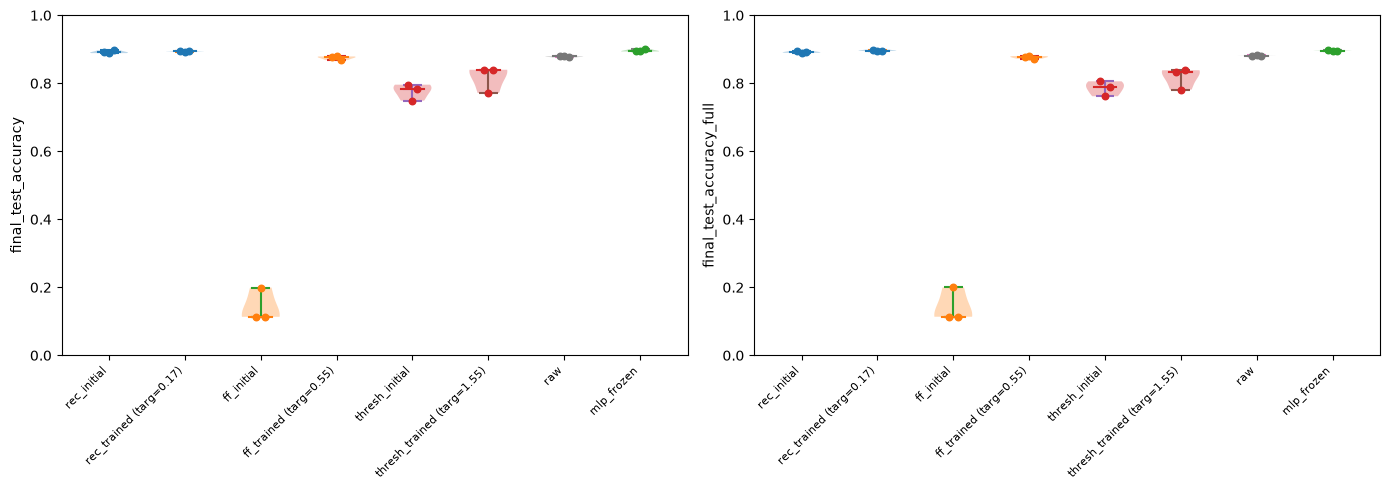

In [10]:
fig, axs = plt.subplots(1, 2, figsize=FIGSIZE)
for ax, metric in zip(axs, ("final_test_accuracy", "final_test_accuracy_full")):
    for i, arm in enumerate(arms):
        _violin_points(ax, chosen.loc[chosen.arm == arm, metric], i, arm_color(arm))
    ax.set_xticks(range(len(arms)), arm_labels, rotation=45, ha="right", fontsize=8)
    ax.set(ylabel=metric, ylim=(0, 1))
figures["G4_final_accuracy"] = fig

figures['G4_final_accuracy'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [11]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'accuracy_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, ['G4_final_accuracy'], ['summary', 'selected_summary', 'accuracy_statistics'])

## 4. Paired seed comparisons

Join trained and initial runs by seed before subtracting. The median paired difference and the difference of group medians are separate columns.

In [12]:
rows, groups = [], []
trained = summary[summary.arm.str.endswith("_trained")]
for (model, targ), g in trained.groupby(["model_code", "targ"]):
    initial = summary[summary.arm == f"{model}_initial"]
    # A paired comparison must retain the same unique seeds on both sides.
    if g.seed_index.duplicated().any() or initial.seed_index.duplicated().any() or set(g.seed_index) != set(initial.seed_index):
        raise ValueError("paired comparison needs unique identical seed sets")
    matched = g.merge(initial, on="seed_index", suffixes=("_trained", "_initial"), validate="one_to_one")
    for metric in ("final_test_accuracy", "final_test_accuracy_full", "final_val_accuracy"):
        values = matched[f"{metric}_trained"] - matched[f"{metric}_initial"]
        for i, r in matched.iterrows():
            rows.append({"model_code": model, "targ": targ, "seed_index": r.seed_index,
                         "metric": metric, "trained": r[f"{metric}_trained"],
                         "initial": r[f"{metric}_initial"], "difference": values.loc[i]})
        # Keep every seed in the detail table; summarize only finite paired changes.
        finite = values[np.isfinite(values)]
        groups.append({"model_code": model, "targ": targ, "metric": metric,
                       "n": len(finite), "expected_n": len(matched),
                       "median_paired_difference": finite.median() if len(finite) else np.nan,
                       "difference_of_medians": g[metric].median() - initial[metric].median()})
tables["paired_accuracy"] = pd.DataFrame(rows)
tables["accuracy_differences"] = pd.DataFrame(groups)

In [13]:
for name in ['paired_accuracy', 'accuracy_differences']:
    print(f"{name}: {len(tables[name])} rows (preview below; export keeps every row)")
    display(tables[name].head(12).rename(columns={"lifetime": "dataset"}).replace({"axis": {"lifetime": "dataset"}}))

paired_accuracy: 243 rows (preview below; export keeps every row)


,model_code,targ,seed_index,metric,trained,initial,difference
0,ff,0.17,0,final_test_accuracy,0.852539,0.113281,0.739258
1,ff,0.17,1,final_test_accuracy,0.881836,0.199219,0.682617
2,ff,0.17,2,final_test_accuracy,0.865234,0.113281,0.751953
3,ff,0.17,0,final_test_accuracy_full,0.849200,0.113500,0.735700
4,ff,0.17,1,final_test_accuracy_full,0.882200,0.199700,0.682500
5,ff,0.17,2,final_test_accuracy_full,0.844700,0.113500,0.731200
6,ff,0.17,0,final_val_accuracy,0.849609,0.114258,0.735352
7,ff,0.17,1,final_val_accuracy,0.889648,0.202148,0.687500
8,ff,0.17,2,final_val_accuracy,0.851562,0.114258,0.737305
9,ff,0.20,0,final_test_accuracy,0.861328,0.113281,0.748047


accuracy_differences: 81 rows (preview below; export keeps every row)


,model_code,targ,metric,n,expected_n,median_paired_difference,difference_of_medians
0,ff,0.17,final_test_accuracy,3,3,0.739258,0.751953
1,ff,0.17,final_test_accuracy_full,3,3,0.731200,0.735700
2,ff,0.17,final_val_accuracy,3,3,0.735352,0.737305
3,ff,0.20,final_test_accuracy,3,3,0.748047,0.758789
4,ff,0.20,final_test_accuracy_full,3,3,0.739600,0.746600
5,ff,0.20,final_val_accuracy,3,3,0.744141,0.746094
6,ff,0.27,final_test_accuracy,3,3,0.757812,0.764648
7,ff,0.27,final_test_accuracy_full,3,3,0.750900,0.759500
8,ff,0.27,final_val_accuracy,3,3,0.754883,0.756836
9,ff,0.35,final_test_accuracy,3,3,0.754883,0.762695


### Paired differences across targets



Edit size, colors, and optional axis limits here; the drawing cell reuses the prepared numbers.

In [14]:
FIGSIZE = (7, 4)
COLORS = dict(MODEL_COLORS)
# Set limits to (min, max); None keeps the figure defaults.
X_LIMITS = None
Y_LIMITS = None

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

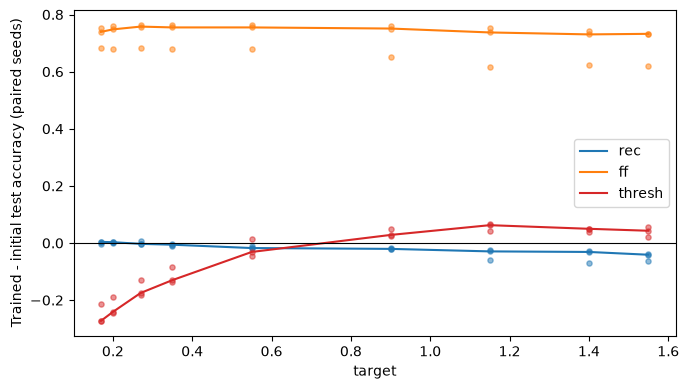

In [15]:
fig, ax = plt.subplots(figsize=FIGSIZE)
paired = tables["paired_accuracy"]
# Show individual paired changes and their median separately at each target.
for model in models:
    g = paired[(paired.model_code == model) & (paired.metric == "final_test_accuracy")]
    _points(ax, g, "targ", "difference", label=model, color=COLORS[model])
ax.axhline(0, color="black", linewidth=.8)
ax.set(xlabel="target", ylabel="Trained - initial test accuracy (paired seeds)")
ax.legend()
figures["G4_paired_difference"] = fig

figures['G4_paired_difference'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [16]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'paired_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, ['G4_paired_difference'], ['paired_accuracy', 'accuracy_differences'])

## 5. Measured learning curves

Validation appears only at actual evaluated steps and at the deduplicated final evaluation. The full saved history still contains every training step.

In [17]:
# Retain all target histories here; drawing cells apply the display selection.
parts = [saved["history"].assign(**_identity(path, conditions))
         for path, (conditions, arrays, saved) in runs.items() if "history" in saved]
tables["history"] = pd.concat(parts, ignore_index=True)

In [18]:
points = []
# Exclude carried-forward validation values and include the final measurement once.
for path, (c, _, t) in selected.items():
    points.append(validation_points(t["history"], t["summary"]).assign(**_identity(path, c)))
tables["validation_points"] = pd.concat(points, ignore_index=True)
tables["validation_trajectory"] = describe_values(tables["validation_points"], ["arm", "step"], ["val_accuracy", "val_loss", "cumulative_l1", "batch_loss"])

In [19]:
for name in ['history', 'validation_points', 'validation_trajectory']:
    print(f"{name}: {len(tables[name])} rows (preview below; export keeps every row)")
    display(tables[name].head(12).rename(columns={"lifetime": "dataset"}).replace({"axis": {"lifetime": "dataset"}}))

history: 23040 rows (preview below; export keeps every row)


,step,epoch,batch_loss,batch_accuracy,l1_delta,cumulative_l1,val_loss,val_accuracy,val_evaluated,run,arm,model_code,targ,eta,seed_index
0,1,0,2.309467,0.140625,14.549945,14.549945,2.200560,0.185547,True,[local path],ff_trained,ff,0.17,0.0003,0
1,2,0,2.225616,0.203125,9.974572,24.524517,2.128546,0.210938,True,[local path],ff_trained,ff,0.17,0.0003,0
2,3,0,2.134034,0.187500,9.162012,33.686529,2.077305,0.259766,True,[local path],ff_trained,ff,0.17,0.0003,0
3,4,0,1.936225,0.296875,8.822096,42.508625,2.026040,0.319336,True,[local path],ff_trained,ff,0.17,0.0003,0
4,5,0,1.977359,0.312500,8.153942,50.662567,1.976828,0.380859,True,[local path],ff_trained,ff,0.17,0.0003,0
5,6,0,2.029226,0.421875,7.346098,58.008666,1.928421,0.430664,True,[local path],ff_trained,ff,0.17,0.0003,0
6,7,0,2.030657,0.375000,6.998542,65.007208,1.880343,0.474609,True,[local path],ff_trained,ff,0.17,0.0003,0
7,8,0,1.844155,0.421875,6.927602,71.934810,1.829908,0.489258,True,[local path],ff_trained,ff,0.17,0.0003,0
8,9,0,1.822477,0.375000,6.740401,78.675211,1.783952,0.512695,True,[local path],ff_trained,ff,0.17,0.0003,0
9,10,0,1.777119,0.593750,6.551792,85.227003,1.740178,0.536133,True,[local path],ff_trained,ff,0.17,0.0003,0


validation_points: 5760 rows (preview below; export keeps every row)


,step,epoch,val_accuracy,val_loss,cumulative_l1,batch_loss,source,run,arm,model_code,targ,eta,seed_index
0,1,0,0.191406,2.258772,14.549950,2.339951,history,[local path],ff_trained,ff,0.55,0.0001,0
1,2,0,0.263672,2.121860,21.618225,2.393493,history,[local path],ff_trained,ff,0.55,0.0001,0
2,3,0,0.297852,2.020656,28.262792,2.081590,history,[local path],ff_trained,ff,0.55,0.0001,0
3,4,0,0.324219,1.948540,34.595618,1.873275,history,[local path],ff_trained,ff,0.55,0.0001,0
4,5,0,0.362305,1.876360,40.814846,1.839972,history,[local path],ff_trained,ff,0.55,0.0001,0
5,6,0,0.479492,1.775428,46.943725,1.921116,history,[local path],ff_trained,ff,0.55,0.0001,0
6,7,0,0.553711,1.684485,53.171538,1.852680,history,[local path],ff_trained,ff,0.55,0.0001,0
7,8,0,0.611328,1.619610,59.216067,1.687874,history,[local path],ff_trained,ff,0.55,0.0001,0
8,9,0,0.604492,1.576322,64.780099,1.723743,history,[local path],ff_trained,ff,0.55,0.0001,0
9,10,0,0.610352,1.528951,70.076012,1.527281,history,[local path],ff_trained,ff,0.55,0.0001,0


validation_trajectory: 7680 rows (preview below; export keeps every row)


,arm,step,metric,expected_n,n,missing_or_invalid,mean,sd,median,q1,q3,min,max
0,ff_initial,1,val_accuracy,3,3,0,0.101237,0.000460,0.101562,0.101074,0.101562,0.100586,0.101562
1,ff_initial,1,val_loss,3,3,0,2.303708,0.000694,2.303219,2.303217,2.303955,2.303216,2.304691
2,ff_initial,1,cumulative_l1,3,3,0,0.129987,0.120818,0.059990,0.044995,0.179980,0.030000,0.299970
3,ff_initial,1,batch_loss,3,3,0,2.301206,0.000913,2.300602,2.300561,2.301550,2.300520,2.302497
4,ff_initial,2,val_accuracy,3,3,0,0.101237,0.000460,0.101562,0.101074,0.101562,0.100586,0.101562
5,ff_initial,2,val_loss,3,3,0,2.303497,0.000401,2.303234,2.303213,2.303649,2.303193,2.304064
6,ff_initial,2,cumulative_l1,3,3,0,0.294002,0.284260,0.095211,0.093004,0.395605,0.090796,0.695998
7,ff_initial,2,batch_loss,3,3,0,2.306311,0.003382,2.305524,2.304071,2.308157,2.302619,2.310790
8,ff_initial,3,val_accuracy,3,3,0,0.101237,0.000460,0.101562,0.101074,0.101562,0.100586,0.101562
9,ff_initial,3,val_loss,3,3,0,2.303282,0.000100,2.303263,2.303217,2.303339,2.303170,2.303414


### Validation accuracy at observed steps



Edit size, colors, and optional axis limits here; the drawing cell reuses the prepared numbers.

In [20]:
FIGSIZE = (9, 4)
COLORS = dict(MODEL_COLORS)
# Set limits to (min, max); None keeps the figure defaults.
X_LIMITS = None
Y_LIMITS = None

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

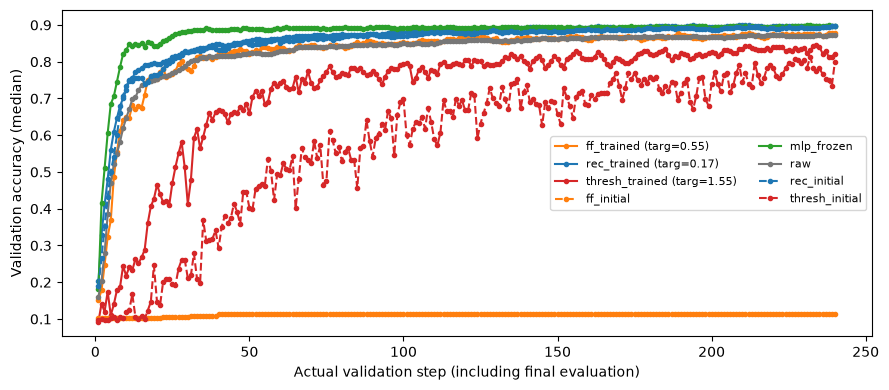

In [21]:
fig, ax = plt.subplots(figsize=FIGSIZE)
p = tables["validation_points"]
# Each marker is a seed median at an observed step; lines only connect markers.
for arm, g in p.groupby("arm", sort=False):
    med = g.groupby("step").val_accuracy.median()
    ax.plot(med.index, med, marker=".", label=_arm_label(arm, targets), color=arm_color(arm), linestyle="--" if arm.endswith("initial") else "-")
ax.set(xlabel="Actual validation step (including final evaluation)", ylabel="Validation accuracy (median)")
ax.legend(fontsize=8, ncol=2)
figures["G5_validation_accuracy"] = fig

figures['G5_validation_accuracy'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Batch and measured validation losses

Edit size and optional axis limits below; the drawing cell reuses the
prepared numbers. Loss curves use Matplotlib's default colors.

In [22]:
FIGSIZE = (16, 7)
COLORS = dict(MODEL_COLORS)
# Set limits to (min, max); None keeps the figure defaults.
X_LIMITS = None
Y_LIMITS = None

def arm_color(arm):
    return COLORS.get(arm.split("_")[0], "#777777" if arm == "raw" else "#2ca02c")

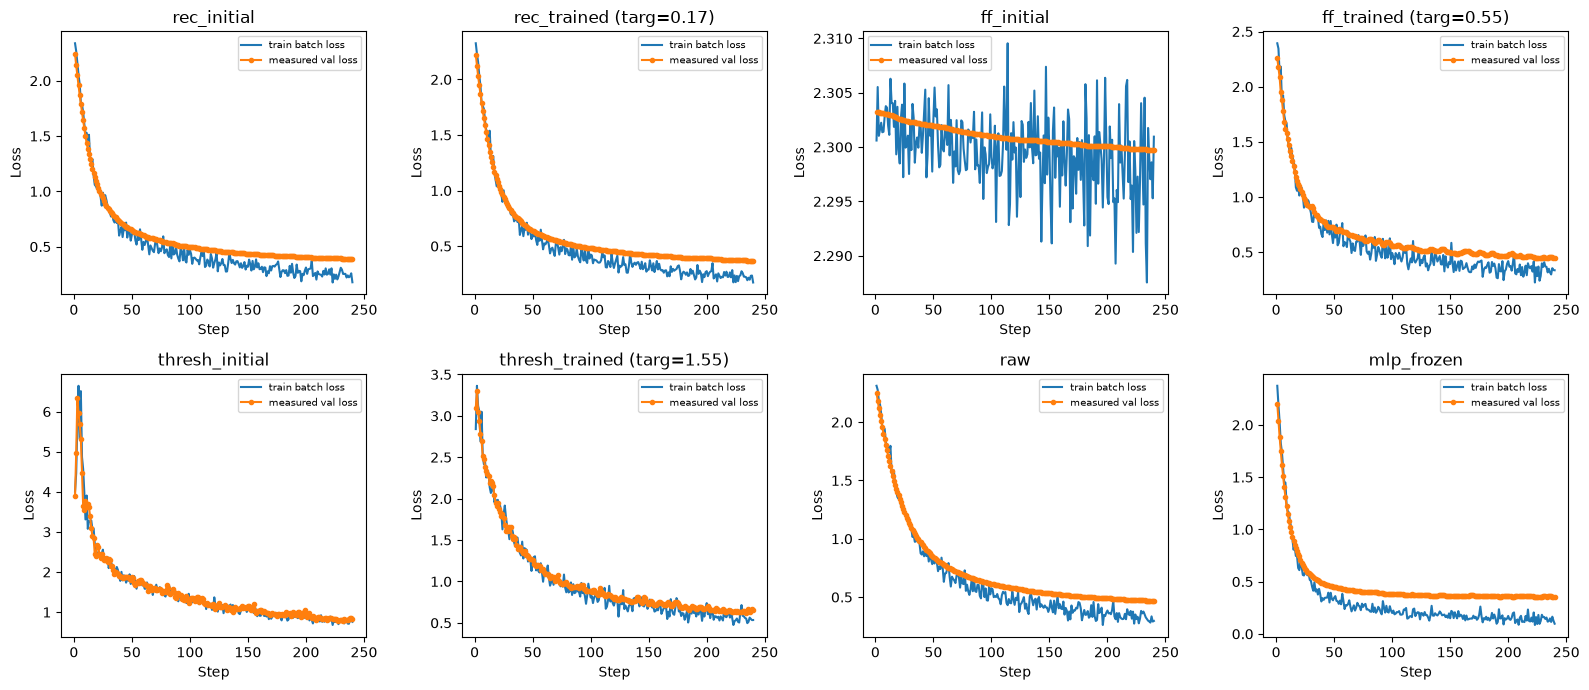

In [23]:
p = tables["validation_points"]
fig, axs = plt.subplots(2, (len(arms)+1)//2, figsize=FIGSIZE, squeeze=False)
h = tables["history"][tables["history"].run.isin(chosen_paths)]
# Aggregate batch and validation losses across seeds on their respective step grids.
for ax, arm in zip(axs.flat, arms):
    batch = h[h.arm == arm].groupby("step").batch_loss.median()
    val = p[p.arm == arm].groupby("step").val_loss.median()
    ax.plot(batch.index, batch, label="train batch loss")
    ax.plot(val.index, val, marker=".", label="measured val loss")
    ax.set(title=_arm_label(arm, targets), xlabel="Step", ylabel="Loss")
    ax.legend(fontsize=7)
for ax in list(axs.flat)[len(arms):]:
    ax.set_visible(False)
figures["G5_losses"] = fig

figures['G5_losses'] = fig
for axis in fig.axes:
    if X_LIMITS is not None: axis.set_xlim(X_LIMITS)
    if Y_LIMITS is not None: axis.set_ylim(Y_LIMITS)
if not fig.get_constrained_layout(): fig.tight_layout()
if SHOW_FIGURES: display(fig)
plt.close(fig)

### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [24]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'curves_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, ['G5_validation_accuracy', 'G5_losses'], ['history', 'validation_points', 'validation_trajectory'])

## 6. Threshold attainment (RF-05)

Thresholds are the adopted fixed list in Python. A run reaches a threshold
if any actual validation observation, including the final one, reaches it.
`fraction` is `reached / total`, where `total` counts valid runs only.
`expected_total` includes all planned runs; `missing_or_invalid` counts
those excluded from the fraction. The fraction is undefined if no run is valid.

`first_observed_step` starts the observation window; it is not the threshold
crossing time. The input check above requires complete results before this
chapter, so missing runs stop normal execution.

In [25]:
pop = _display_population(expected, targets)
rows = []
for r in pop.itertuples():
    points, reason = None, r.reason
    config = {key: getattr(r, key, np.nan) for key in ("readout_epochs", "readout_eval_every", "batch_size")}
    if r.state == "complete" and r.run in runs:
        c, _, t = runs[r.run]
        config = c["config"]
        try:
            issues = readout_issues(c, t, require_history=True)
            if issues:
                raise ValueError("; ".join(issues))
            points = validation_points(t["history"], t["summary"])
        except (ValueError, KeyError) as exc:
            reason = str(exc)
    # Keep one row per planned run and threshold, including unusable histories.
    for threshold in THRESHOLDS:
        valid = points is not None
        reached = valid and bool((points.val_accuracy >= threshold).any())
        rows.append({"run": r.run, "arm": r.arm, "model_code": r.model_code,
                     "targ": r.targ, "seed_index": r.seed_index, "threshold": threshold,
                     "judgement": "reached" if reached else "unreached" if valid else "invalid",
                     "reason": "" if valid else reason or r.state,
                     "n_observed": len(points) if valid else 0,
                     "first_observed_step": points.step.min() if valid else np.nan,
                     "final_step": points.step.max() if valid else np.nan,
                     "final_source": points.source.iloc[-1] if valid else "",
                     "eval_every": config.get("readout_eval_every", np.nan),
                     "readout_epochs": config.get("readout_epochs", np.nan)})
detail = pd.DataFrame(rows)
if detail.empty:
    raise ValueError("No planned population for explicit targets")

In [26]:
# The fraction uses valid runs; expected_total also counts invalid planned runs.
aggregates = []
for (arm, threshold), g in detail.groupby(["arm", "threshold"], sort=True):
    n = int(g.judgement.ne("invalid").sum())
    reached = int(g.judgement.eq("reached").sum())
    aggregates.append({"arm": arm, "threshold": threshold, "reached": reached, "total": n,
                       "fraction": reached / n if n else np.nan, "expected_total": len(g),
                       "missing_or_invalid": len(g) - n})
tables["threshold_detail"] = detail
tables["threshold_summary"] = pd.DataFrame(aggregates)

In [27]:
for name in ['threshold_detail', 'threshold_summary']:
    print(f"{name}: {len(tables[name])} rows (preview below; export keeps every row)")
    display(tables[name].head(12).rename(columns={"lifetime": "dataset"}).replace({"axis": {"lifetime": "dataset"}}))

threshold_detail: 168 rows (preview below; export keeps every row)


,run,arm,model_code,targ,seed_index,threshold,judgement,reason,n_observed,first_observed_step,final_step,final_source,eval_every,readout_epochs
0,[local path],ff_trained,ff,0.55,0,0.30,reached,,240,1,240,history+summary,1,15
1,[local path],ff_trained,ff,0.55,0,0.40,reached,,240,1,240,history+summary,1,15
2,[local path],ff_trained,ff,0.55,0,0.50,reached,,240,1,240,history+summary,1,15
3,[local path],ff_trained,ff,0.55,0,0.60,reached,,240,1,240,history+summary,1,15
4,[local path],ff_trained,ff,0.55,0,0.70,reached,,240,1,240,history+summary,1,15
5,[local path],ff_trained,ff,0.55,0,0.80,reached,,240,1,240,history+summary,1,15
6,[local path],ff_trained,ff,0.55,0,0.85,reached,,240,1,240,history+summary,1,15
7,[local path],ff_trained,ff,0.55,1,0.30,reached,,240,1,240,history+summary,1,15
8,[local path],ff_trained,ff,0.55,1,0.40,reached,,240,1,240,history+summary,1,15
9,[local path],ff_trained,ff,0.55,1,0.50,reached,,240,1,240,history+summary,1,15


threshold_summary: 56 rows (preview below; export keeps every row)


,arm,threshold,reached,total,fraction,expected_total,missing_or_invalid
0,ff_initial,0.30,0,3,0.0,3,0
1,ff_initial,0.40,0,3,0.0,3,0
2,ff_initial,0.50,0,3,0.0,3,0
3,ff_initial,0.60,0,3,0.0,3,0
4,ff_initial,0.70,0,3,0.0,3,0
5,ff_initial,0.80,0,3,0.0,3,0
6,ff_initial,0.85,0,3,0.0,3,0
7,ff_trained,0.30,3,3,1.0,3,0
8,ff_trained,0.40,3,3,1.0,3,0
9,ff_trained,0.50,3,3,1.0,3,0


### Save this chapter (optional)

Set this switch to True and choose a new export name. Save the notebook before
running this cell. Other chapters and notebooks do not need to be exported first.

In [28]:
SAVE_SECTION = False
SECTION_EXPORT_NAME = 'thresholds_v1'
if SAVE_SECTION:
    export_section(SECTION_EXPORT_NAME, [], ['threshold_detail', 'threshold_summary'])

## Export all figures and tables in this notebook

Run all main chapters first. Set `SAVE_NUMBERS=True` in Settings and choose
a new `EXPORT_NAME`. This saves the CSVs listed in `OWNED_TABLES`, prepared
main-chapter figures in the enabled formats, input/HP/population hashes,
effective targets, a notebook copy, and export settings.

Chapter exports must use different names. Save the notebook file before
exporting; after style changes, rerun the drawing cells and use a new name.

Optional saved-parameter inference and fixed-point checks are implemented in
[02_adaptation.ipynb](02_adaptation.ipynb). Optional UMAP fits are implemented
in [05_geometry.ipynb](05_geometry.ipynb). Each has its own computation switch
and can redraw from saved additional numbers.

In [29]:
print("Tables owned by this notebook:", OWNED_TABLES)
print("Figures prepared:", list(figures))
if SAVE_NUMBERS:
    export_section(EXPORT_NAME, list(figures), OWNED_TABLES)
else:
    print("Preview only. Enable SAVE_NUMBERS and choose a new EXPORT_NAME to export.")

Tables owned by this notebook: ['summary', 'selected_summary', 'accuracy_statistics', 'paired_accuracy', 'accuracy_differences', 'history', 'validation_points', 'validation_trajectory', 'threshold_detail', 'threshold_summary']
Figures prepared: ['G4_final_accuracy', 'G4_paired_difference', 'G5_validation_accuracy', 'G5_losses']
Preview only. Enable SAVE_NUMBERS and choose a new EXPORT_NAME to export.
